# Fuzzy Logic Penentuan Risiko Diabetes Berdasarkan Usia dan BMI 
Penentuan risiko diabetes ini menggunakan metode logika fuzzy dengan dua variabel input yaitu usia dan BMI (Body Mass Index / indeks massa tubuh) yang dibagi menjadi beberapa tahapan:

- **Fuzzification**  
  Nilai usia dan BMI dimasukkan ke dalam sistem sebagai data awal yang bersifat tegas (crisp). Nilai crisp diubah menjadi degree of membership pada beberapa himpunan fuzzy untuk variabel usia dan BMI.

- **Inference / Rule Evaluation**  
  Hasil fuzzification berupa nilai keanggotaan yang digunakan sebagai input pada proses inferensi (Fuzzy input). Sistem menggunakan aturan IF–THEN untuk menentukan hubungan antara usia dan BMI terhadap tingkat risiko diabetes.

- **Defuzzification**  
  Hasil inferensi yang masih berbentuk fuzzy kemudian diubah menjadi nilai tegas (crisp output). Pada notebook ini digunakan tiga pendekatan defuzzification, yaitu **Sugeno**, **Max Method**, dan **Mamdani (Centroid)**, sehingga hasil akhirnya dapat dibandingkan.

BMI dihitung dengan rumus:


BMI = Berat Badan / Tinggi Badan * Tinggi Badan


Secara umum, kategori BMI dewasa yang digunakan mengikuti klasifikasi WHO:
- **underweight** : BMI < 18.5  
- **healthy weight** : BMI 18.5 – 24.9  
- **overweight** : BMI 25.0 – 29.9  
- **obese** : BMI ≥ 30.0


In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

## Crisp Input

Data awal dimasukkan ke dalam sistem dalam bentuk nilai crisp (numerik). Pada contoh ini digunakan dua variabel utama untuk sistem fuzzy yaitu **usia** dan **BMI** dari beberapa pasien.  

Agar BMI lebih realistis, data dummy juga dilengkapi dengan **berat badan** dan **tinggi badan**, lalu BMI dihitung menggunakan rumus standar. Data tersebut kemudian digunakan sebagai dasar pada tahap fuzzification dalam sistem fuzzy.


In [60]:
data = pd.DataFrame({
    "Pasien":    ["P1","P2","P3","P4","P5","P6","P7","P8"],
    "Usia":      [24, 33, 69, 52, 68, 20, 38, 58],
    "Berat_kg":  [45, 68, 78, 95, 70, 82, 55, 105],
    "Tinggi_cm": [170, 165, 168, 158, 170, 185, 178, 160]
})

data["BMI"] = data["Berat_kg"] / (data["Tinggi_cm"] / 100) ** 2
data["BMI"] = data["BMI"].round(2)
data

,Pasien,Usia,Berat_kg,Tinggi_cm,BMI
0,P1,24,45,170,15.5700
1,P2,33,68,165,24.9800
2,P3,69,78,168,27.6400
3,P4,52,95,158,38.0500
4,P5,68,70,170,24.2200
5,P6,20,82,185,23.9600
6,P7,38,55,178,17.3600
7,P8,58,105,160,41.0200


## Membership Function

Pada sistem fuzzy, membership function digunakan untuk menentukan derajat keanggotaan suatu nilai pada himpunan fuzzy. Dalam implementasi ini digunakan dua jenis fungsi keanggotaan, yaitu triangular membership function (trimf) dan trapezoidal membership function (trapmf).

- **trimf (Triangular Membership Function)**  
  Fungsi ini membentuk kurva segitiga yang ditentukan oleh tiga parameter (a, b, c). Nilai keanggotaan meningkat secara linear dari a ke b, mencapai nilai maksimum 1 di titik b, kemudian menurun secara linear dari b ke c.

- **trapmf (Trapezoidal Membership Function)**  
  Fungsi ini membentuk kurva trapesium yang ditentukan oleh empat parameter (a, b, c, d). Nilai keanggotaan meningkat dari a ke b, bernilai 1 pada interval b hingga c, kemudian menurun dari c ke d.


In [61]:
def trimf(x, a, b, c):
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x, dtype=float)

    if b != a:
        idx = (a < x) & (x < b)
        y[idx] = (x[idx] - a) / (b - a)

    y[x == b] = 1.0

    if c != b:
        idx = (b < x) & (x < c)
        y[idx] = (c - x[idx]) / (c - b)

    return np.clip(y, 0, 1)


def trapmf(x, a, b, c, d):
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x, dtype=float)

    if b != a:
        idx = (a < x) & (x < b)
        y[idx] = (x[idx] - a) / (b - a)
    else:
        y[(x >= a) & (x <= b)] = 1.0

    y[(x >= b) & (x <= c)] = 1.0

    if d != c:
        idx = (c < x) & (x < d)
        y[idx] = (d - x[idx]) / (d - c)
    else:
        y[(x >= c) & (x <= d)] = 1.0

    return np.clip(y, 0, 1)

## Definisi Variabel Fuzzy

Pada tahap ini ditentukan domain nilai dan fungsi keanggotaan untuk setiap variabel yang digunakan dalam sistem fuzzy, yaitu **usia**, **BMI**, dan **risiko diabetes**.

- **Usia (19–100 tahun)**  
  Variabel usia dibagi menjadi tiga kategori fuzzy:
  - young (19 - 39 tahun) 
  - middle (45 - 64 tahun)
  - old (70 - 100 tahun)

- **BMI (12–45 kg/m²)**  
  Variabel BMI dibagi menjadi empat kategori fuzzy:
  - underweight (<=18.5) 
  - healthy_weight ()
  - overweight  
  - obese  

  Batas kategori BMI mengikuti klasifikasi WHO untuk orang dewasa, dengan overlap fuzzy di sekitar batas 18.5, 25.0, dan 30.0 agar transisi antarkategori tidak bersifat kaku.

- **Risiko Diabetes (0–100)**  
  Variabel output dibagi menjadi tiga kategori fuzzy:
  - kecil  
  - sedang  
  - tinggi


In [62]:
usia = np.linspace(19, 100, 1000)
bmi = np.linspace(12, 45, 1000)
risiko = np.linspace(0, 100, 1000)

young  = trapmf(usia, 19, 19, 39, 45)
middle = trapmf(usia, 40, 45, 64, 70)
old    = trapmf(usia, 65, 70, 100, 100)

bmi_underweight = trapmf(bmi, 12.0, 12.0, 17.0, 20.0)
bmi_healthy     = trapmf(bmi, 18.0, 20.5, 23.5, 27.0)
bmi_overweight  = trapmf(bmi, 24.5, 27.0, 29.5, 32.5)
bmi_obese       = trapmf(bmi, 30.0, 33.0, 45.0, 45.0)

risiko_kecil  = trapmf(risiko, 0, 0, 20, 40)
risiko_sedang = trimf(risiko, 30, 50, 70)
risiko_tinggi = trapmf(risiko, 60, 80, 100, 100)


## Visualisasi Membership Function

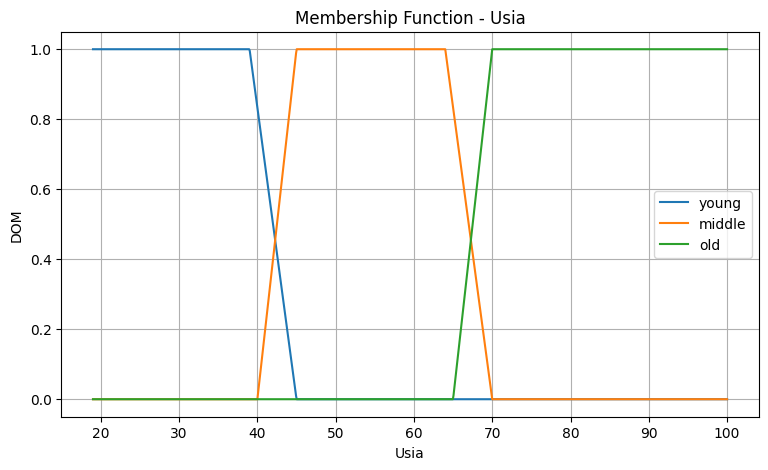

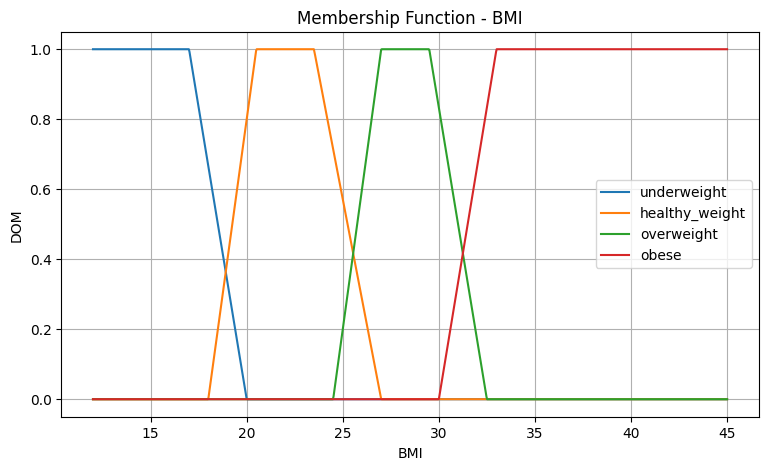

In [63]:
plt.figure()
plt.plot(usia, young, label="young")
plt.plot(usia, middle, label="middle")
plt.plot(usia, old, label="old")
plt.title("Membership Function - Usia")
plt.xlabel("Usia")
plt.ylabel("DOM")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(bmi, bmi_underweight, label="underweight")
plt.plot(bmi, bmi_healthy, label="healthy_weight")
plt.plot(bmi, bmi_overweight, label="overweight")
plt.plot(bmi, bmi_obese, label="obese")
plt.title("Membership Function - BMI")
plt.xlabel("BMI")
plt.ylabel("DOM")
plt.legend()
plt.grid(True)
plt.show()


## Rule Base (IF–THEN)

Aturan fuzzy yang digunakan adalah sebagai berikut:

1. IF **usia = young** AND **BMI = underweight** THEN **risiko = kecil**  
2. IF **usia = young** AND **BMI = healthy_weight** THEN **risiko = kecil**  
3. IF **usia = young** AND **BMI = overweight** THEN **risiko = sedang**  
4. IF **usia = young** AND **BMI = obese** THEN **risiko = tinggi**  

5. IF **usia = middle** AND **BMI = underweight** THEN **risiko = kecil**  
6. IF **usia = middle** AND **BMI = healthy_weight** THEN **risiko = sedang**  
7. IF **usia = middle** AND **BMI = overweight** THEN **risiko = tinggi**  
8. IF **usia = middle** AND **BMI = obese** THEN **risiko = tinggi**  

9. IF **usia = old** AND **BMI = underweight** THEN **risiko = sedang**  
10. IF **usia = old** AND **BMI = healthy_weight** THEN **risiko = sedang**  
11. IF **usia = old** AND **BMI = overweight** THEN **risiko = tinggi**  
12. IF **usia = old** AND **BMI = obese** THEN **risiko = tinggi**  

Rule base ini disusun dengan mempertimbangkan dua pola utama yang banyak dilaporkan pada literatur:  
(1) **risiko diabetes cenderung meningkat seiring bertambahnya usia**, dan  
(2) **BMI yang lebih tinggi (overweight/obese) berkaitan dengan peningkatan risiko diabetes tipe 2**.  

Karena itu, kombinasi **usia lebih tua** dan **BMI lebih tinggi** dipetakan ke risiko yang lebih besar, sedangkan **young + healthy_weight** dipetakan ke risiko kecil.


In [64]:
rules = [
    ("young",  "underweight",    "kecil"),
    ("young",  "healthy_weight", "kecil"),
    ("young",  "overweight",     "sedang"),
    ("young",  "obese",          "tinggi"),

    ("middle", "underweight",    "kecil"),
    ("middle", "healthy_weight", "sedang"),
    ("middle", "overweight",     "tinggi"),
    ("middle", "obese",          "tinggi"),

    ("old",    "underweight",    "sedang"),
    ("old",    "healthy_weight", "sedang"),
    ("old",    "overweight",     "tinggi"),
    ("old",    "obese",          "tinggi"),
]
rules


[('young', 'underweight', 'kecil'),
 ('young', 'healthy_weight', 'kecil'),
 ('young', 'overweight', 'sedang'),
 ('young', 'obese', 'tinggi'),
 ('middle', 'underweight', 'kecil'),
 ('middle', 'healthy_weight', 'sedang'),
 ('middle', 'overweight', 'tinggi'),
 ('middle', 'obese', 'tinggi'),
 ('old', 'underweight', 'sedang'),
 ('old', 'healthy_weight', 'sedang'),
 ('old', 'overweight', 'tinggi'),
 ('old', 'obese', 'tinggi')]

## Fuzzification 

In [65]:
def fuzzify(u, b):

    usia_val = {
        "young":  float(trapmf([u], 19, 19, 39, 45)[0]),
        "middle": float(trapmf([u], 40, 45, 64, 70)[0]),
        "old":    float(trapmf([u], 65, 70, 100, 100)[0]),
    }

    bmi_val = {
        "underweight":    float(trapmf([b], 12.0, 12.0, 17.0, 20.0)[0]),
        "healthy_weight": float(trapmf([b], 18.0, 20.5, 23.5, 27.0)[0]),
        "overweight":     float(trapmf([b], 24.5, 27.0, 29.5, 32.5)[0]),
        "obese":          float(trapmf([b], 30.0, 33.0, 45.0, 45.0)[0]),
    }

    return usia_val, bmi_val


## Inference

In [66]:
def inference(u, b):
    usia_val, bmi_val = fuzzify(u, b)

    rows = []
    for age_label, bmi_label, out_label in rules:
        alpha = min(usia_val[age_label], bmi_val[bmi_label])
        rows.append({
            "usia_set": age_label,
            "bmi_set": bmi_label,
            "output": out_label,
            "alpha": alpha
        })

    return pd.DataFrame(rows)


## Defuzzification - Sugeno

In [67]:
def sugeno(u, b):
    df = inference(u, b).copy()

    z_map = {
        "kecil": 25.0,
        "sedang": 50.0,
        "tinggi": 75.0
    }

    df["z"] = df["output"].map(z_map)

    df["alpha_z"] = df["alpha"] * df["z"]

    denom = df["alpha"].sum()
    if denom == 0:
        return 0.0, df

    crisp = df["alpha_z"].sum() / denom

    return float(crisp), df

## Defuzzification - Max Method

In [68]:
def max_method(u, b):
    df = inference(u, b)

    # agregasi output, ambil alpha terbesar
    agg = df.groupby("output", as_index=False)["alpha"].max()
    label = agg.loc[agg["alpha"].idxmax(), "output"]

    z_map = {
        "kecil": 25.0,
        "sedang": 50.0,
        "tinggi": 75.0
    }
    return float(z_map[label]), df, agg

## Defuzzification - Mamdani

In [69]:
def mamdani(u, b):
    df = inference(u, b)

    alpha_kecil = df.loc[df["output"] == "kecil", "alpha"].max()
    alpha_sedang = df.loc[df["output"] == "sedang", "alpha"].max()
    alpha_tinggi = df.loc[df["output"] == "tinggi", "alpha"].max()

    kecil_cut = np.minimum(alpha_kecil, risiko_kecil)
    sedang_cut = np.minimum(alpha_sedang, risiko_sedang)
    tinggi_cut = np.minimum(alpha_tinggi, risiko_tinggi)

    aggregated = np.maximum(kecil_cut, np.maximum(sedang_cut, tinggi_cut))

    if np.sum(aggregated) == 0:
        return 0.0, df, aggregated

    crisp = np.sum(risiko * aggregated) / np.sum(aggregated)
    return float(crisp), df, aggregated

## Hasil Fuzzification

In [70]:
sample = data.iloc[1]   
u = float(sample["Usia"])
b = float(sample["BMI"])

print("Pasien:")
print(sample)

usia_val, bmi_val = fuzzify(u, b)

print("\nDerajat keanggotaan usia:")
print(pd.Series(usia_val))

print("\nDerajat keanggotaan BMI:")
print(pd.Series(bmi_val))


Pasien:
Pasien           P2
Usia             33
Berat_kg         68
Tinggi_cm       165
BMI         24.9800
Name: 1, dtype: object

Derajat keanggotaan usia:
young    1.0000
middle   0.0000
old      0.0000
dtype: float64

Derajat keanggotaan BMI:
underweight      0.0000
healthy_weight   0.5771
overweight       0.1920
obese            0.0000
dtype: float64


## Hasil Inference / Rules Evaluation

In [71]:
from IPython.display import display

df_inf = inference(u, b)
usia_val, bmi_val = fuzzify(u, b)

print("\nHasil inference:")
display(df_inf)

col_usia   = "usia_set"
col_bmi    = "bmi_set"
col_output = "output"
col_alpha  = "alpha"

usia_order = ["young", "middle", "old"]
bmi_order = ["underweight", "healthy_weight", "overweight", "obese"]

df_inf[col_usia] = pd.Categorical(df_inf[col_usia], categories=usia_order, ordered=True)
df_inf[col_bmi] = pd.Categorical(df_inf[col_bmi], categories=bmi_order, ordered=True)

tbl_output = df_inf.pivot_table(
    index=col_usia,
    columns=col_bmi,
    values=col_output,
    aggfunc="first",
    observed=False
).reindex(index=usia_order, columns=bmi_order)

tbl_alpha = df_inf.pivot_table(
    index=col_usia,
    columns=col_bmi,
    values=col_alpha,
    aggfunc="first",
    observed=False
).reindex(index=usia_order, columns=bmi_order)

print("\nTabel output rules:")
display(tbl_output)

print("\nTabel alpha tiap rule:")
display(tbl_alpha)



Hasil inference:


,usia_set,bmi_set,output,alpha
0,young,underweight,kecil,0.0000
1,young,healthy_weight,kecil,0.5771
2,young,overweight,sedang,0.1920
3,young,obese,tinggi,0.0000
4,middle,underweight,kecil,0.0000
5,middle,healthy_weight,sedang,0.0000
6,middle,overweight,tinggi,0.0000
7,middle,obese,tinggi,0.0000
8,old,underweight,sedang,0.0000
9,old,healthy_weight,sedang,0.0000



Tabel output rules:


bmi_set,underweight,healthy_weight,overweight,obese
usia_set,,,,
young,kecil,kecil,sedang,tinggi
middle,kecil,sedang,tinggi,tinggi
old,sedang,sedang,tinggi,tinggi



Tabel alpha tiap rule:


bmi_set,underweight,healthy_weight,overweight,obese
usia_set,,,,
young,0.0000,0.5771,0.1920,0.0000
middle,0.0000,0.0000,0.0000,0.0000
old,0.0000,0.0000,0.0000,0.0000


## Hasil Defuzzification - Max Method

In [72]:
z_max, df_max, agg_max = max_method(u, b)

print("=== HASIL MAX METHOD ===")
print("Nilai Crisp :", z_max)

print("\n=== Tabel Inference ===")
display(df_max)

print("\n=== Tabel Aggregation ===")
display(agg_max)

=== HASIL MAX METHOD ===
Nilai Crisp : 25.0

=== Tabel Inference ===


,usia_set,bmi_set,output,alpha
0,young,underweight,kecil,0.0000
1,young,healthy_weight,kecil,0.5771
2,young,overweight,sedang,0.1920
3,young,obese,tinggi,0.0000
4,middle,underweight,kecil,0.0000
5,middle,healthy_weight,sedang,0.0000
6,middle,overweight,tinggi,0.0000
7,middle,obese,tinggi,0.0000
8,old,underweight,sedang,0.0000
9,old,healthy_weight,sedang,0.0000



=== Tabel Aggregation ===


,output,alpha
0,kecil,0.5771
1,sedang,0.1920
2,tinggi,0.0000


## Hasil Defuzification - Sugeno

In [73]:
z_sugeno, df_sug = sugeno(u, b)

print("=== HASIL SUGENO ===")
print("Nilai Crisp :", z_sugeno)

print("\n=== Tabel Inference Sugeno ===")
display(df_sug)

=== HASIL SUGENO ===
Nilai Crisp : 31.240713224368506

=== Tabel Inference Sugeno ===


,usia_set,bmi_set,output,alpha,z,alpha_z
0,young,underweight,kecil,0.0000,25.0000,0.0000
1,young,healthy_weight,kecil,0.5771,25.0000,14.4286
2,young,overweight,sedang,0.1920,50.0000,9.6000
3,young,obese,tinggi,0.0000,75.0000,0.0000
4,middle,underweight,kecil,0.0000,25.0000,0.0000
5,middle,healthy_weight,sedang,0.0000,50.0000,0.0000
6,middle,overweight,tinggi,0.0000,75.0000,0.0000
7,middle,obese,tinggi,0.0000,75.0000,0.0000
8,old,underweight,sedang,0.0000,50.0000,0.0000
9,old,healthy_weight,sedang,0.0000,50.0000,0.0000


## Hasil Defuzzification - Mamdani

In [74]:
z_mamdani, df_mam, agg_mam = mamdani(u, b)

print("=== HASIL MAMDANI ===")
print("Nilai Crisp :", z_mamdani)

print("\n=== Tabel Inference ===")
display(df_mam)


=== HASIL MAMDANI ===
Nilai Crisp : 25.3305441543228

=== Tabel Inference ===


,usia_set,bmi_set,output,alpha
0,young,underweight,kecil,0.0000
1,young,healthy_weight,kecil,0.5771
2,young,overweight,sedang,0.1920
3,young,obese,tinggi,0.0000
4,middle,underweight,kecil,0.0000
5,middle,healthy_weight,sedang,0.0000
6,middle,overweight,tinggi,0.0000
7,middle,obese,tinggi,0.0000
8,old,underweight,sedang,0.0000
9,old,healthy_weight,sedang,0.0000


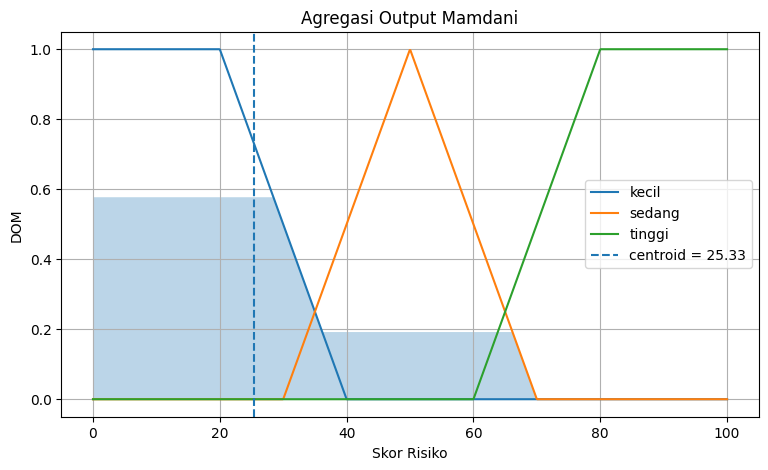

In [75]:
plt.figure()
plt.plot(risiko, risiko_kecil, label="kecil")
plt.plot(risiko, risiko_sedang, label="sedang")
plt.plot(risiko, risiko_tinggi, label="tinggi")
plt.fill_between(risiko, 0, agg_mam, alpha=0.3)
plt.axvline(z_mamdani, linestyle="--", label=f"centroid = {z_mamdani:.2f}")
plt.title("Agregasi Output Mamdani")
plt.xlabel("Skor Risiko")
plt.ylabel("DOM")
plt.legend()
plt.grid(True)
plt.show()

## Catatan Referensi

Dasar penentuan kategori BMI dan rule base diringkas dari literatur berikut:

1. **WHO**: kategori BMI dewasa menggunakan batas **underweight < 18.5**, **normal/healthy 18.5–24.9**, **overweight 25.0–29.9**, dan **obesity ≥ 30.0**.  
2. **Ganz et al. (2014)** menunjukkan bahwa dibanding BMI normal, kelompok **overweight** dan **obesity** memiliki risiko diagnosis diabetes tipe 2 yang lebih tinggi, dan risikonya meningkat pada kategori BMI yang lebih tinggi.  
3. **Fazeli et al. (2019)** dan **Yan et al. (2023)** menekankan bahwa **usia** merupakan faktor risiko penting, dan pada kelompok usia lebih tua, overweight/obesity makin memperbesar risiko diabetes.

Rule fuzzy pada notebook ini bukan guideline klinis formal, tetapi representasi pengetahuan berbasis literatur untuk kebutuhan studi komparatif metode defuzzification.


## Perbandingan Hasil 3 Metode Defuzzification

In [76]:
rows = []
for _, r in data.iterrows():
    u = float(r["Usia"])
    b = float(r["BMI"])

    z_max, _, _ = max_method(u, b)
    z_sug, _ = sugeno(u, b)
    z_mam, _, _ = mamdani(u, b)

    rows.append({
        "Pasien": r["Pasien"],
        "Usia": u,
        "BMI": b,
        "Max": z_max,
        "Sugeno": z_sug,
        "Mamdani": z_mam,
    })

result = pd.DataFrame(rows)
result


,Pasien,Usia,BMI,Max,Sugeno,Mamdani
0,P1,24.0000,15.5700,25.0000,25.0000,15.5296
1,P2,33.0000,24.9800,25.0000,31.2407,25.3305
2,P3,69.0000,27.6400,75.0000,75.0000,83.6922
3,P4,52.0000,38.0500,75.0000,75.0000,84.4704
4,P5,68.0000,24.2200,50.0000,50.0000,50.0000
5,P6,20.0000,23.9600,25.0000,25.0000,16.0330
6,P7,38.0000,17.3600,25.0000,25.0000,15.9880
7,P8,58.0000,41.0200,75.0000,75.0000,84.4704


## Visualisasi Perbandingan

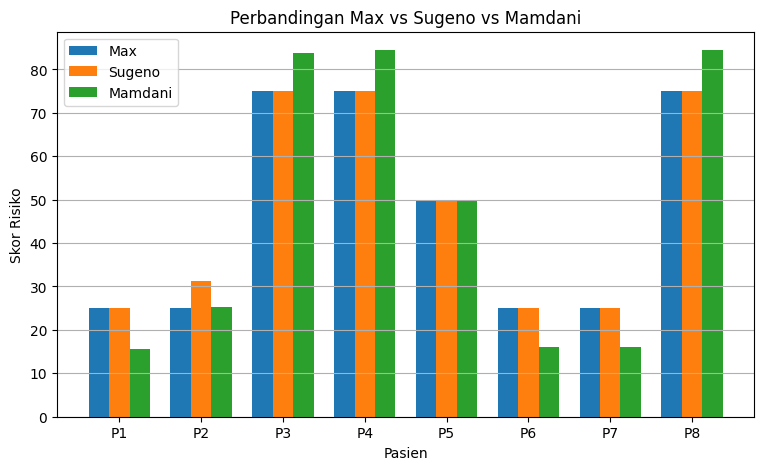

In [77]:
x = np.arange(len(result))
w = 0.25

plt.figure()
plt.bar(x - w, result["Max"], width=w, label="Max")
plt.bar(x, result["Sugeno"], width=w, label="Sugeno")
plt.bar(x + w, result["Mamdani"], width=w, label="Mamdani")

plt.xticks(x, result["Pasien"])
plt.xlabel("Pasien")
plt.ylabel("Skor Risiko")
plt.title("Perbandingan Max vs Sugeno vs Mamdani")
plt.legend()
plt.grid(True, axis="y")
plt.show()